# Classification des radiographies pulmonaires COVID-19 — CNN custom Clahe_True Augmentation_True

Ce notebook repart du notebook **`03_radiographie_covid_classification_CNN_Custom_TF_Keras_Houssein_fixed_splits.ipynb`** et ajoute :

1. une version **plus simple** de la gestion des chemins en faisant l'hypothèse que les CSV de `dataset_splits` sont corrects ;
2. une **sauvegarde du modèle** et des artefacts de sortie pour pouvoir réutiliser le modèle sans réentraîner ;
3. une section d'**interprétabilité** avec **Grad-CAM** et **SHAP** sur des exemples :
   - **bien classés**
   - **mal classés**
   - pour **chaque catégorie** quand un exemple est disponible.

L'objectif est de garder une forte continuité avec les notebooks précédents :
- mêmes 4 classes ;
- mêmes CSV `train / val / test` ;
- même logique de prétraitement ;
- mêmes sorties d'évaluation.

In [ ]:
# # =========================
# # Installation (Google Colab)
# # =========================
# # TensorFlow est généralement déjà présent.
# # On installe ici les bibliothèques annexes nécessaires au pipeline.

# !pip -q install kagglehub opencv-python scikit-learn seaborn shap

In [ ]:
# =========================
# Imports et environnement
# =========================

import gc
import json
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

print("TensorFlow version :", tf.__version__)
print("GPU disponible     :", tf.config.list_physical_devices("GPU"))

# Reproductibilité
SEED = 42
keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
    print("Déterminisme TensorFlow activé.")
except Exception as e:
    print("Déterminisme non activé :", e)

2026-05-22 12:42:48.520542: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779453768.681918      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779453768.731525      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779453769.117575      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779453769.117610      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779453769.117613      57 computation_placer.cc:177] computation placer alr

TensorFlow version : 2.19.0
GPU disponible     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Déterminisme TensorFlow activé.


In [ ]:
# =========================
# Configuration générale
# =========================
# Toute la configuration utile est centralisée ici.
# C'est la cellule à modifier en priorité si tu veux faire varier le pipeline.

# -------------------------
# Dossier des splits CSV
# -------------------------
# Ici, on suppose explicitement que les CSV sont bons et qu'ils se trouvent
# dans /content/dataset_splits sur Colab.
SPLITS_DIR = Path("/kaggle/input/datasets/housseinabbouchi/dataset-splits/")

TRAIN_CSV = SPLITS_DIR / "train_df.csv"
VAL_CSV   = SPLITS_DIR / "val_df.csv"
TEST_CSV  = SPLITS_DIR / "test_df.csv"

# -------------------------
# Classes / labels
# -------------------------
CATEGORIES = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]
NUM_CLASSES = len(CATEGORIES)

CLASS_TO_ID = {label: idx for idx, label in enumerate(CATEGORIES)}
ID_TO_CLASS = {idx: label for label, idx in CLASS_TO_ID.items()}

# -------------------------
# Prétraitement images
# -------------------------
TARGET_SIZE = 128
N_CHANNELS = 1

APPLY_MASK = True
APPLY_CLAHE = True

CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_SIZE = (8, 8)

# -------------------------
# Data augmentation
# -------------------------
USE_AUGMENTATION = True

AUG_ROTATION = 0.05
AUG_TRANSLATION = 0.03
AUG_ZOOM = 0.05
AUG_CONTRAST = 0.08

# -------------------------
# tf.data
# -------------------------
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
CACHE_DATASET = False   # Laisser False si la RAM est juste

# -------------------------
# Entraînement
# -------------------------
TRAIN_MODEL = True             # False = on recharge un modèle sauvegardé
USE_CLASS_WEIGHTS = True
EPOCHS = 20
LEARNING_RATE = 1e-3

# -------------------------
# Sauvegarde
# -------------------------
SAVE_DIR = Path("//kaggle/working/saved_models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = SAVE_DIR / "best_custom_cnn_fixed_splits.keras"
FINAL_MODEL_PATH = SAVE_DIR / "final_custom_cnn_fixed_splits.keras"
HISTORY_CSV_PATH = SAVE_DIR / "custom_cnn_history.csv"
REPORT_CSV_PATH = SAVE_DIR / "classification_report_test.csv"
RESULTS_CSV_PATH = SAVE_DIR / "test_predictions_detailed.csv"
CONFIG_JSON_PATH = SAVE_DIR / "run_config.json"

# -------------------------
# Interprétabilité
# -------------------------
LAST_CONV_LAYER_NAME = None    # None = détection automatique de la dernière couche Conv2D

## 1. Chargement des splits figés

Dans cette version, on **fait confiance** aux fichiers CSV du dossier `dataset_splits`.
On ne cherche plus plusieurs emplacements possibles : cela allège le notebook et rend la logique plus lisible.

Les CSV doivent contenir au moins :
- `label`
- `image_path`
- `mask_path`

In [5]:
# =========================
# Chargement des CSV de split
# =========================

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("train_df :", train_df.shape)
print("val_df   :", val_df.shape)
print("test_df  :", test_df.shape)

display(train_df.head())

train_df : (14815, 3)
val_df   : (3175, 3)
test_df  : (3175, 3)


,label,image_path,mask_path
0,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
1,Lung_Opacity,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
2,Viral Pneumonia,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
3,Normal,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
4,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...


In [6]:
# =========================
# Téléchargement / localisation du dataset Kaggle
# =========================
# Les CSV ont été générés dans un environnement Kaggle.
# Sur Colab, on télécharge le dataset puis on remappe les chemins.

import kagglehub

data_path = Path(kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database"))
print("Dataset Kaggle localisé dans :", data_path)

candidate_root = data_path / "COVID-19_Radiography_Dataset"
if candidate_root.exists():
    dataset_root = candidate_root
else:
    dataset_root = next(p for p in data_path.rglob("COVID-19_Radiography_Dataset") if p.is_dir())

print("dataset_root =", dataset_root)

Dataset Kaggle localisé dans : /kaggle/input/datasets/tawsifurrahman/covid19-radiography-database
dataset_root = /kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset


In [7]:
# =========================
# Remapping des chemins CSV -> chemins locaux Colab
# =========================
# Hypothèse choisie ici :
# - les CSV sont corrects ;
# - ils pointent vers des chemins de type :
#   /kaggle/input/.../COVID-19_Radiography_Dataset/<classe>/<images|masks>/<fichier>
#
# On reconstruit donc simplement le suffixe après
# "COVID-19_Radiography_Dataset/" et on le recolle à dataset_root.

def remap_csv_path_to_local(csv_path: str, dataset_root: Path):
    csv_path = str(csv_path)
    marker = "COVID-19_Radiography_Dataset/"
    suffix = csv_path.split(marker, 1)[1]
    return str(dataset_root / suffix)

def prepare_split_df(df):
    out = df.copy()
    out["image_path_local"] = out["image_path"].apply(lambda p: remap_csv_path_to_local(p, dataset_root))
    out["mask_path_local"] = out["mask_path"].apply(lambda p: remap_csv_path_to_local(p, dataset_root))
    out["label_id"] = out["label"].map(CLASS_TO_ID).astype(np.int32)
    return out

train_df = prepare_split_df(train_df)
val_df   = prepare_split_df(val_df)
test_df  = prepare_split_df(test_df)

display(train_df.head())

,label,image_path,mask_path,image_path_local,mask_path_local,label_id
0,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/datasets/tawsifurrahman/covid19-...,/kaggle/input/datasets/tawsifurrahman/covid19-...,0
1,Lung_Opacity,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/datasets/tawsifurrahman/covid19-...,/kaggle/input/datasets/tawsifurrahman/covid19-...,2
2,Viral Pneumonia,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/datasets/tawsifurrahman/covid19-...,/kaggle/input/datasets/tawsifurrahman/covid19-...,3
3,Normal,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/datasets/tawsifurrahman/covid19-...,/kaggle/input/datasets/tawsifurrahman/covid19-...,1
4,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/datasets/tawsifurrahman/covid19-...,/kaggle/input/datasets/tawsifurrahman/covid19-...,0


In [8]:
# =========================
# Sauvegarde de la configuration de run
# =========================
# On enregistre la config pour garder une trace du contexte d'entraînement.

run_config = {
    "seed": SEED,
    "categories": CATEGORIES,
    "target_size": TARGET_SIZE,
    "n_channels": N_CHANNELS,
    "apply_mask": APPLY_MASK,
    "apply_clahe": APPLY_CLAHE,
    "use_augmentation": USE_AUGMENTATION,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "splits_dir": str(SPLITS_DIR),
    "dataset_root": str(dataset_root),
}

with open(CONFIG_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(run_config, f, indent=2, ensure_ascii=False)

print("Configuration sauvegardée dans :", CONFIG_JSON_PATH)

Configuration sauvegardée dans : //kaggle/working/saved_models/run_config.json


,split,class_name,count
0,train,COVID,2531
1,train,Normal,7134
2,train,Lung_Opacity,4208
3,train,Viral Pneumonia,942
4,validation,COVID,543
5,validation,Normal,1529
6,validation,Lung_Opacity,902
7,validation,Viral Pneumonia,201
8,test,COVID,542
9,test,Normal,1529


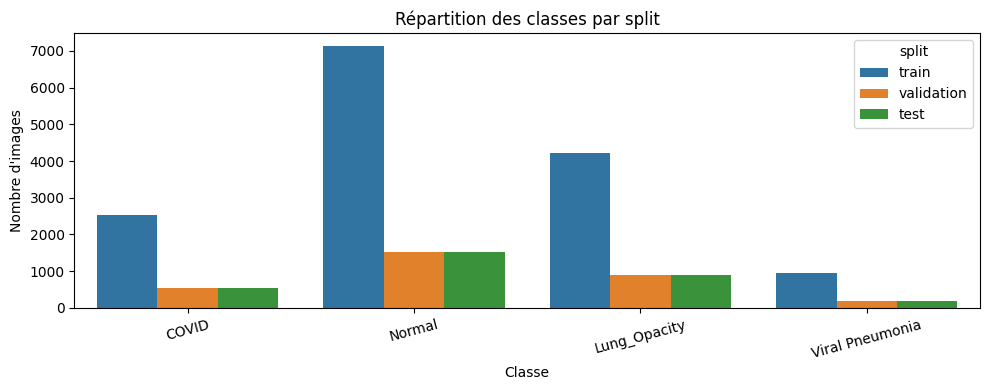

In [9]:
# =========================
# Répartition des classes par split
# =========================

def make_split_distribution(df, split_name):
    counts = df["label"].value_counts().reindex(CATEGORIES)
    return pd.DataFrame({
        "split": split_name,
        "class_name": CATEGORIES,
        "count": counts.values
    })

split_dist_df = pd.concat([
    make_split_distribution(train_df, "train"),
    make_split_distribution(val_df, "validation"),
    make_split_distribution(test_df, "test"),
], ignore_index=True)

display(split_dist_df)

plt.figure(figsize=(10, 4))
sns.barplot(data=split_dist_df, x="class_name", y="count", hue="split")
plt.title("Répartition des classes par split")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

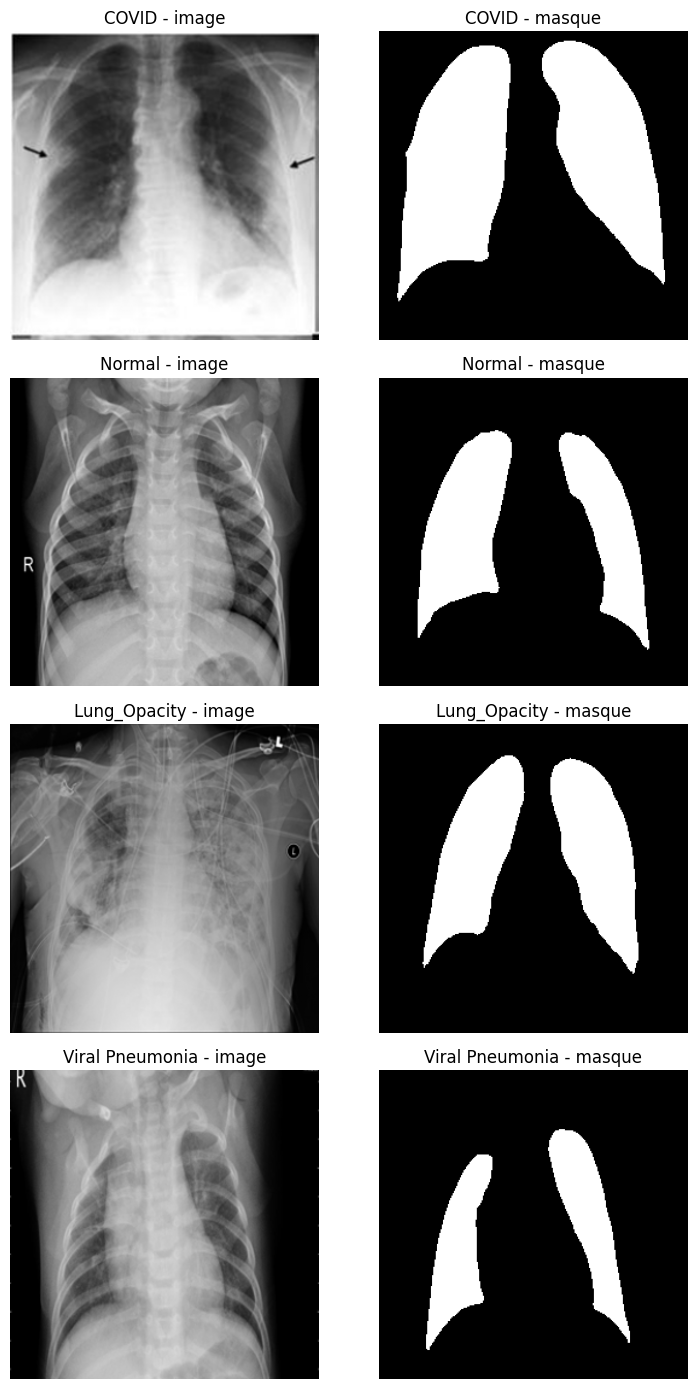

In [10]:
# =========================
# Vérification visuelle rapide
# =========================
# On affiche un exemple image + masque pour chaque classe.

fig, axes = plt.subplots(len(CATEGORIES), 2, figsize=(8, 14))

for i, category in enumerate(CATEGORIES):
    row = train_df[train_df["label"] == category].iloc[0]

    img = cv2.imread(row["image_path_local"], cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(row["mask_path_local"], cv2.IMREAD_GRAYSCALE)

    axes[i, 0].imshow(img, cmap="gray")
    axes[i, 0].set_title(f"{category} - image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title(f"{category} - masque")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

## 2. Prétraitement et pipeline `tf.data`

Le prétraitement reste cohérent avec les notebooks précédents :
- lecture en **grayscale**
- application du **masque pulmonaire**
- **resize 128×128**
- **CLAHE** optionnel
- **normalisation** entre `0` et `1`

In [11]:
# =========================
# Fonctions de prétraitement
# =========================

clahe = cv2.createCLAHE(
    clipLimit=CLAHE_CLIP_LIMIT,
    tileGridSize=CLAHE_TILE_SIZE
)

def preprocess_image_with_mask_numpy(image_path, mask_path):
    '''
    Prétraitement exécuté côté Python / NumPy / OpenCV.
    Cette fonction est appelée depuis tf.data via tf.numpy_function.

    Sortie :
        image float32 de forme (TARGET_SIZE, TARGET_SIZE, 1)
    '''
    image_path = image_path.decode("utf-8")
    mask_path = mask_path.decode("utf-8")

    # Lecture de l'image en niveaux de gris
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Impossible de lire l'image : {image_path}")

    # Lecture du masque si demandé
    mask = None
    if APPLY_MASK:
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # Application du masque pulmonaire
    if APPLY_MASK and mask is not None:
        mask = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
        mask = (mask > 0).astype(np.uint8)
        img = img * mask

    # Redimensionnement
    img = cv2.resize(img, (TARGET_SIZE, TARGET_SIZE), interpolation=cv2.INTER_AREA)

    # CLAHE pour renforcer localement le contraste
    if APPLY_CLAHE:
        img = clahe.apply(img)

    # Normalisation [0, 1]
    img = img.astype(np.float32) / 255.0

    # Ajout du canal
    img = np.expand_dims(img, axis=-1)  # (H, W) -> (H, W, 1)
    return img

def tf_preprocess(image_path, mask_path, label):
    '''
    Wrapper TensorFlow pour intégrer le prétraitement NumPy/OpenCV
    dans un pipeline tf.data.
    '''
    image = tf.numpy_function(
        func=preprocess_image_with_mask_numpy,
        inp=[image_path, mask_path],
        Tout=[tf.float32]
    )[0]
    image.set_shape((TARGET_SIZE, TARGET_SIZE, N_CHANNELS))
    label = tf.cast(label, tf.int32)
    return image, label

def make_dataset(df, training=False):
    '''
    Construit un tf.data.Dataset à partir d'un DataFrame de split.
    '''
    ds = tf.data.Dataset.from_tensor_slices((
        df["image_path_local"].astype(str).values,
        df["mask_path_local"].astype(str).values,
        df["label_id"].values
    ))

    ds = ds.map(tf_preprocess, num_parallel_calls=AUTOTUNE)

    if CACHE_DATASET:
        ds = ds.cache()

    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

In [12]:
# =========================
# Class weights
# =========================
# On calcule les poids uniquement sur le split train.

classes = np.array(sorted(train_df["label_id"].unique()))
class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label_id"].values
)

class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights_values)}
print("Class weights :", class_weight_dict)

Class weights : {0: 1.4633544053733702, 1: 0.5191687692738997, 2: 0.8801687262357415, 3: 3.9317940552016983}


In [13]:
# =========================
# Pipelines tf.data
# =========================

train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df, training=False)
test_ds  = make_dataset(test_df, training=False)

for batch_images, batch_labels in train_ds.take(1):
    print("Shape images batch :", batch_images.shape)
    print("Shape labels batch :", batch_labels.shape)

I0000 00:00:1779453794.314514      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779453794.320493      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
2026-05-22 12:43:15.961057: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be 

Shape images batch : (32, 128, 128, 1)
Shape labels batch : (32,)


In [14]:
# =========================
# Bloc de data augmentation (optionnel)
# =========================
# Si USE_AUGMENTATION = False, ce bloc est ignoré.
# Les transformations restent volontairement modérées.

def build_augmentation_layer():
    return keras.Sequential(
        [
            layers.RandomRotation(AUG_ROTATION, seed=SEED),
            layers.RandomTranslation(AUG_TRANSLATION, AUG_TRANSLATION, seed=SEED),
            layers.RandomZoom(AUG_ZOOM, seed=SEED),
            layers.RandomContrast(AUG_CONTRAST, seed=SEED),
        ],
        name="data_augmentation"
    )

## 3. CNN custom

On garde l'architecture custom du notebook précédent, avec :
- 4 blocs convolutionnels ;
- BatchNorm ;
- Dropout progressif ;
- GlobalAveragePooling ;
- tête dense légère.

In [15]:
# =========================
# Définition du modèle CNN custom
# =========================

def conv_block(x, filters, dropout_rate, block_name):
    x = layers.Conv2D(filters, (3, 3), padding="same", use_bias=False, name=f"{block_name}_conv1")(x)
    x = layers.BatchNormalization(name=f"{block_name}_bn1")(x)
    x = layers.ReLU(name=f"{block_name}_relu1")(x)

    x = layers.Conv2D(filters, (3, 3), padding="same", use_bias=False, name=f"{block_name}_conv2")(x)
    x = layers.BatchNormalization(name=f"{block_name}_bn2")(x)
    x = layers.ReLU(name=f"{block_name}_relu2")(x)

    x = layers.MaxPooling2D((2, 2), name=f"{block_name}_pool")(x)
    x = layers.Dropout(dropout_rate, name=f"{block_name}_dropout")(x)
    return x

def build_custom_cnn(input_shape=(TARGET_SIZE, TARGET_SIZE, N_CHANNELS), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape, name="input_image")
    x = inputs

    if USE_AUGMENTATION:
        x = build_augmentation_layer()(x)

    x = conv_block(x, 32, 0.10, "block1")
    x = conv_block(x, 64, 0.15, "block2")
    x = conv_block(x, 128, 0.20, "block3")
    x = conv_block(x, 256, 0.25, "block4")

    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = layers.Dense(128, activation="relu", name="dense_128")(x)
    x = layers.Dropout(0.30, name="head_dropout")(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    return keras.Model(inputs, outputs, name="custom_cnn_xray")

model = build_custom_cnn()
model.summary()

Model: "custom_cnn_xray"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn1 (BatchNormalization) │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu1 (ReLU)             │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn2 (BatchNormalization) │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu2 (ReLU)             │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_dropout (Dropout)        │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn1 (BatchNormalization) │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu1 (ReLU)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn2 (BatchNormalization) │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu2 (ReLU)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_dropout (Dropout)        │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn1 (BatchNormalization) │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu1 (ReLU)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn2 (BatchNormalization) │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu2 (ReLU)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             

 Total params: 1,207,972 (4.61 MB)

 Trainable params: 1,206,052 (4.60 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [16]:
# =========================
# Compilation du modèle
# =========================

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
# =========================
# Callbacks
# =========================
# - EarlyStopping pour éviter le surapprentissage
# - ReduceLROnPlateau pour adapter le learning rate
# - ModelCheckpoint pour sauvegarder le meilleur modèle validé

callbacks_list = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [18]:
# =========================
# Entraînement OU rechargement d'un modèle existant
# =========================
# Ce bloc te permet :
# - soit d'entraîner le modèle ;
# - soit de recharger un modèle déjà sauvegardé.

history = None
history_df = None

if TRAIN_MODEL:
    fit_kwargs = dict(
        x=train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks_list,
        verbose=1
    )

    if USE_CLASS_WEIGHTS:
        fit_kwargs["class_weight"] = class_weight_dict

    history = model.fit(**fit_kwargs)

    # Sauvegarde du modèle final
    model.save(FINAL_MODEL_PATH)
    print("Modèle final sauvegardé dans :", FINAL_MODEL_PATH)

    # Sauvegarde de l'historique d'entraînement
    history_df = pd.DataFrame(history.history)
    history_df.to_csv(HISTORY_CSV_PATH, index=False)
    print("Historique sauvegardé dans :", HISTORY_CSV_PATH)

else:
    load_path = BEST_MODEL_PATH if BEST_MODEL_PATH.exists() else FINAL_MODEL_PATH
    model = keras.models.load_model(load_path)
    print("Modèle rechargé depuis :", load_path)

    if HISTORY_CSV_PATH.exists():
        history_df = pd.read_csv(HISTORY_CSV_PATH)
        print("Historique rechargé depuis :", HISTORY_CSV_PATH)

Epoch 1/20


2026-05-22 12:47:33.655231: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_5}}
E0000 00:00:1779454058.426101      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/custom_cnn_xray_1/block1_dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 0

463/463 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.5040 - loss: 1.0139
Epoch 1: val_loss improved from inf to 1.30709, saving model to //kaggle/working/saved_models/best_custom_cnn_fixed_splits.keras
463/463 ━━━━━━━━━━━━━━━━━━━━ 177s 213ms/step - accuracy: 0.5041 - loss: 1.0136 - val_accuracy: 0.4907 - val_loss: 1.3071 - learning_rate: 0.0010
Epoch 2/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.6626 - loss: 0.6916
Epoch 2: val_loss improved from 1.30709 to 0.82039, saving model to //kaggle/working/saved_models/best_custom_cnn_fixed_splits.keras
463/463 ━━━━━━━━━━━━━━━━━━━━ 144s 150ms/step - accuracy: 0.6626 - loss: 0.6916 - val_accuracy: 0.6813 - val_loss: 0.8204 - learning_rate: 0.0010
Epoch 3/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.7130 - loss: 0.6142
Epoch 3: val_loss improved from 0.82039 to 0.75375, saving model to //kaggle/working/saved_models/best_custom_cnn_fixed_splits.keras
463/463 ━━━━━━━━━━━━━━━━━━━━ 139s 147ms/step - accuracy: 0.713

In [19]:
# =========================
# Exemple de rechargement manuel ultérieur
# =========================
# À relancer plus tard si tu veux récupérer le modèle sans repasser par model.fit()

# reloaded_model = keras.models.load_model(BEST_MODEL_PATH)
# reloaded_model.summary()

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.574013,0.859585,0.490709,1.307089,0.001
1,0.675397,0.672673,0.681260,0.820392,0.001
2,0.719069,0.609526,0.699528,0.753747,0.001
3,0.736078,0.575759,0.231496,3.316691,0.001
4,0.749443,0.560989,0.745512,0.691027,0.001


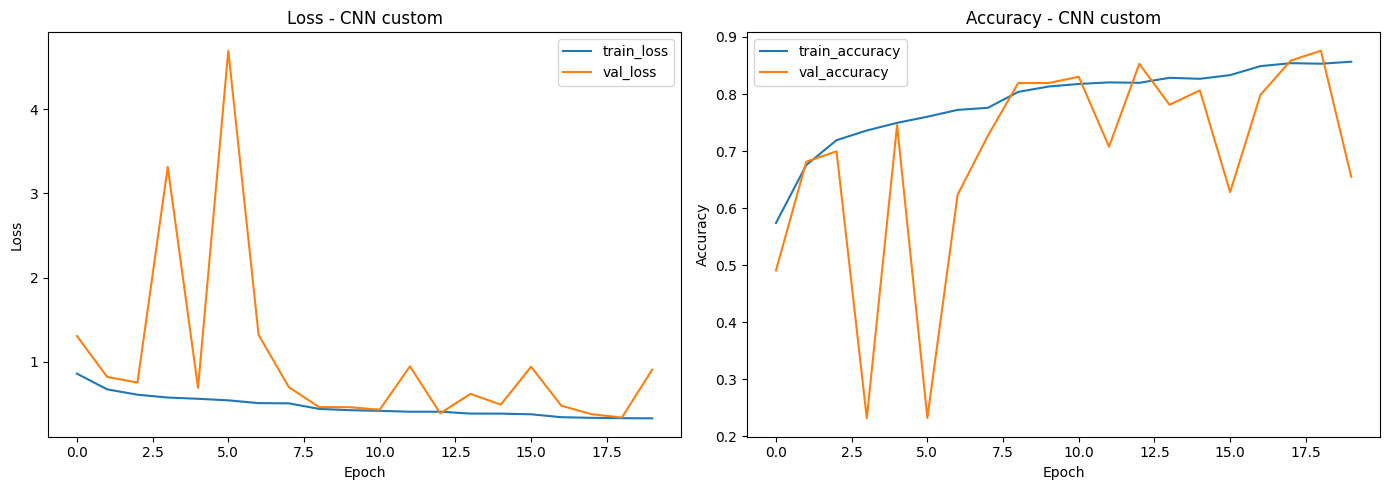

In [20]:
# =========================
# Courbes d'apprentissage
# =========================

if history_df is not None and len(history_df) > 0:
    display(history_df.head())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history_df["loss"], label="train_loss")
    axes[0].plot(history_df["val_loss"], label="val_loss")
    axes[0].set_title("Loss - CNN custom")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history_df["accuracy"], label="train_accuracy")
    axes[1].plot(history_df["val_accuracy"], label="val_accuracy")
    axes[1].set_title("Accuracy - CNN custom")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("Pas d'historique disponible à afficher.")

## 4. Évaluation sur le test set

Comme dans les notebooks précédents, on calcule :
- la loss et l'accuracy globales ;
- le `classification_report` ;
- la matrice de confusion ;
- un tableau détaillé par classe.

En plus, on enregistre un **fichier détaillé de prédictions** qui servira à la sélection des exemples pour Grad-CAM et SHAP.

In [21]:
# =========================
# Évaluation sur le jeu de test
# =========================

test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_acc:.4f}")

y_proba = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_proba, axis=1)
y_test = test_df["label_id"].values

report = classification_report(
    y_test,
    y_pred,
    target_names=CATEGORIES,
    digits=4,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
display(report_df)

report_df.to_csv(REPORT_CSV_PATH, index=True)
print("Classification report sauvegardé dans :", REPORT_CSV_PATH)

# Tableau détaillé de prédictions
test_results_df = test_df.copy()
test_results_df["y_true"] = y_test
test_results_df["y_pred"] = y_pred
test_results_df["true_name"] = test_results_df["y_true"].map(ID_TO_CLASS)
test_results_df["pred_name"] = test_results_df["y_pred"].map(ID_TO_CLASS)
test_results_df["is_correct"] = test_results_df["y_true"] == test_results_df["y_pred"]
test_results_df["pred_confidence"] = y_proba.max(axis=1)

for class_id, class_name in ID_TO_CLASS.items():
    test_results_df[f"proba_{class_name}"] = y_proba[:, class_id]

display(test_results_df.head())

test_results_df.to_csv(RESULTS_CSV_PATH, index=False)
print("Prédictions détaillées sauvegardées dans :", RESULTS_CSV_PATH)

100/100 ━━━━━━━━━━━━━━━━━━━━ 51s 510ms/step - accuracy: 0.8742 - loss: 0.3442
Test loss     : 0.3410
Test accuracy : 0.8750
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 200ms/step


,precision,recall,f1-score,support
COVID,0.795918,0.791513,0.793710,542.000000
Normal,0.907203,0.914323,0.910749,1529.000000
Lung_Opacity,0.849558,0.851441,0.850498,902.000000
Viral Pneumonia,0.958115,0.905941,0.931298,202.000000
accuracy,0.874961,0.874961,0.874961,0.874961
macro avg,0.877699,0.865804,0.871564,3175.000000
weighted avg,0.875068,0.874961,0.874960,3175.000000


Classification report sauvegardé dans : //kaggle/working/saved_models/classification_report_test.csv


,label,image_path,mask_path,image_path_local,mask_path_local,label_id,y_true,y_pred,true_name,pred_name,is_correct,pred_confidence,proba_COVID,proba_Normal,proba_Lung_Opacity,proba_Viral Pneumonia
0,Normal,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/datasets/tawsifurrahman/covid19-...,/kaggle/input/datasets/tawsifurrahman/covid19-...,1,1,1,Normal,Normal,True,0.870654,0.056651,0.870654,0.072633,0.000063
1,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/datasets/tawsifurrahman/covid19-...,/kaggle/input/datasets/tawsifurrahman/covid19-...,0,0,2,COVID,Lung_Opacity,False,0.662931,0.336346,0.000533,0.662931,0.000190
2,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/datasets/tawsifurrahman/covid19-...,/kaggle/input/datasets/tawsifurrahman/covid19-...,0,0,1,COVID,Normal,False,0.723743,0.248341,0.723743,0.027912,0.000004
3,Viral Pneumonia,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/datasets/tawsifurrahman/covid19-...,/kaggle/input/datasets/tawsifurrahman/covid19-...,3,3,3,Viral Pneumonia,Viral Pneumonia,True,0.901484,0.064894,0.031973,0.001649,0.901484
4,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/datasets/tawsifurrahman/covid19-...,/kaggle/input/datasets/tawsifurrahman/covid19-...,0,0,2,COVID,Lung_Opacity,False,0.680047,0.319772,0.000174,0.680047,0.000006


Prédictions détaillées sauvegardées dans : //kaggle/working/saved_models/test_predictions_detailed.csv


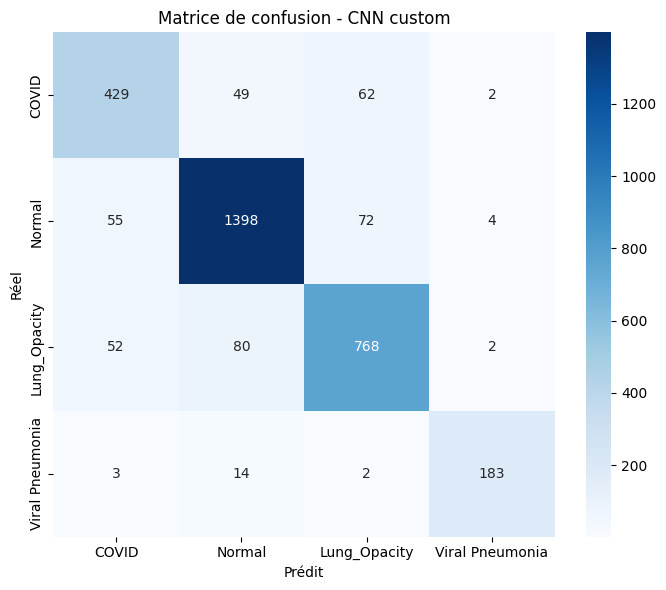

In [22]:
# =========================
# Matrice de confusion
# =========================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CATEGORIES,
    yticklabels=CATEGORIES
)
plt.title("Matrice de confusion - CNN custom")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.show()

In [23]:
# =========================
# Tableau de métriques par classe
# =========================

per_class_df = report_df.loc[CATEGORIES, ["precision", "recall", "f1-score", "support"]].copy()
per_class_df = per_class_df.reset_index().rename(columns={"index": "class_name"})
display(per_class_df)

,class_name,precision,recall,f1-score,support
0,COVID,0.795918,0.791513,0.793710,542.0
1,Normal,0.907203,0.914323,0.910749,1529.0
2,Lung_Opacity,0.849558,0.851441,0.850498,902.0
3,Viral Pneumonia,0.958115,0.905941,0.931298,202.0


## 5. Sélection d'exemples pour l'interprétabilité

On va maintenant sélectionner, dans le **test set** :

- un exemple **bien classé** par catégorie ;
- un exemple **mal classé** par catégorie ;

quand ces exemples existent.

Cette stratégie permet de comparer :
- ce que le modèle regarde quand il réussit ;
- ce qu'il regarde quand il se trompe.

In [24]:
# =========================
# Sélection d'exemples corrects / incorrects par catégorie
# =========================

def select_examples_for_interpretability(results_df, categories):
    '''
    Pour chaque vraie classe :
    - on prend un exemple correct (si disponible)
    - on prend un exemple incorrect (si disponible)

    Le tri par confiance rend les cas plus parlants :
    - cas correct : on prend un exemple bien reconnu
    - cas incorrect : on prend une erreur "sûre" du modèle
    '''
    selected_rows = []

    for category in categories:
        class_id = CLASS_TO_ID[category]
        subset = results_df[results_df["y_true"] == class_id].copy()

        correct_subset = subset[subset["is_correct"]].sort_values("pred_confidence", ascending=False)
        wrong_subset   = subset[~subset["is_correct"]].sort_values("pred_confidence", ascending=False)

        if len(correct_subset) > 0:
            row = correct_subset.iloc[0].copy()
            row["example_type"] = "correct"
            selected_rows.append(row)

        if len(wrong_subset) > 0:
            row = wrong_subset.iloc[0].copy()
            row["example_type"] = "incorrect"
            selected_rows.append(row)

    if len(selected_rows) == 0:
        return pd.DataFrame()

    return pd.DataFrame(selected_rows).reset_index(drop=True)

examples_df = select_examples_for_interpretability(test_results_df, CATEGORIES)
display(examples_df[["label", "example_type", "true_name", "pred_name", "pred_confidence"]])

,label,example_type,true_name,pred_name,pred_confidence
0,COVID,correct,COVID,COVID,0.999572
1,COVID,incorrect,COVID,Lung_Opacity,0.992834
2,Normal,correct,Normal,Normal,0.999667
3,Normal,incorrect,Normal,Lung_Opacity,0.984502
4,Lung_Opacity,correct,Lung_Opacity,Lung_Opacity,0.999882
5,Lung_Opacity,incorrect,Lung_Opacity,Normal,0.991175
6,Viral Pneumonia,correct,Viral Pneumonia,Viral Pneumonia,1.000000
7,Viral Pneumonia,incorrect,Viral Pneumonia,Lung_Opacity,0.986734


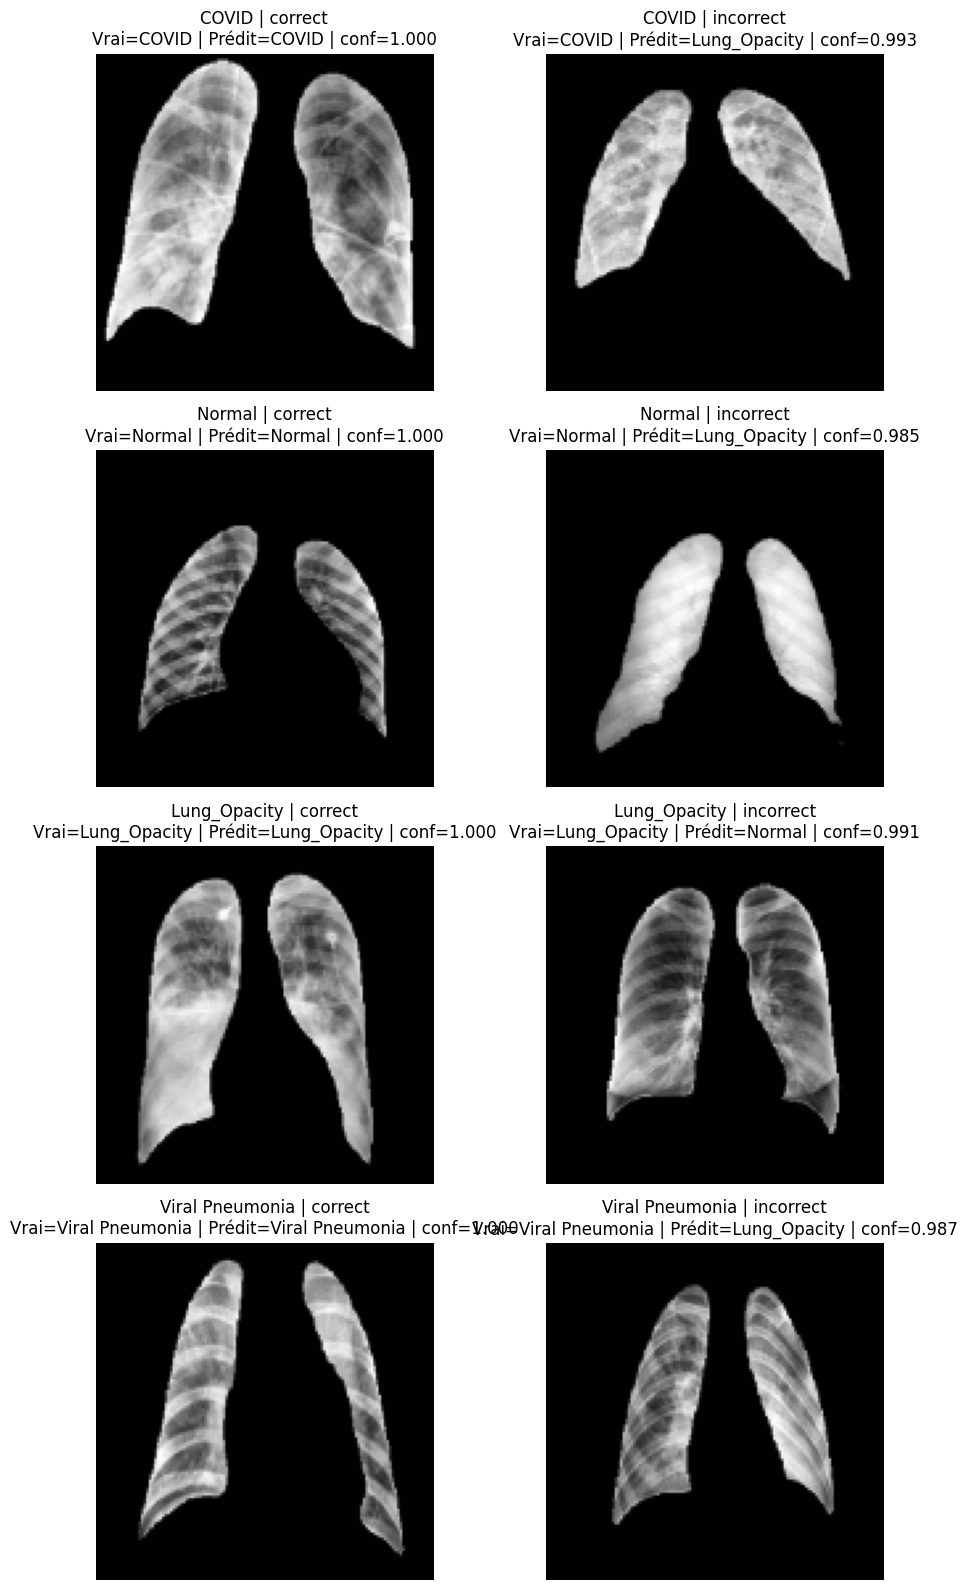

In [25]:
# =========================
# Visualisation des exemples sélectionnés
# =========================

def load_preprocessed_image_from_row(row):
    '''
    Recharge UNE image via exactement le même prétraitement que celui utilisé
    pendant l'entraînement / l'évaluation.
    '''
    image = preprocess_image_with_mask_numpy(
        row["image_path_local"].encode("utf-8"),
        row["mask_path_local"].encode("utf-8")
    )
    return image

def show_selected_examples(examples_df):
    if len(examples_df) == 0:
        print("Aucun exemple disponible.")
        return

    n = len(examples_df)
    cols = 2
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(10, 4 * rows))

    for i, (_, row) in enumerate(examples_df.iterrows()):
        img = load_preprocessed_image_from_row(row)

        ax = plt.subplot(rows, cols, i + 1)
        plt.imshow(img.squeeze(), cmap="gray")
        plt.axis("off")
        plt.title(
            f"{row['true_name']} | {row['example_type']}\n"
            f"Vrai={row['true_name']} | Prédit={row['pred_name']} | conf={row['pred_confidence']:.3f}"
        )

    plt.tight_layout()
    plt.show()

show_selected_examples(examples_df)

## 6. Grad-CAM

Pour les cas **corrects**, on visualise la carte Grad-CAM de la **classe prédite**.

Pour les cas **incorrects**, on visualise :
- la carte Grad-CAM de la **classe prédite** ;
- et la carte Grad-CAM de la **vraie classe**.

Cela permet de comparer ce que le réseau a réellement activé pour l'erreur.

In [26]:
# =========================
# Outils Grad-CAM
# =========================

def get_last_conv_layer_name(model):
    conv_layers = [layer.name for layer in model.layers if isinstance(layer, layers.Conv2D)]
    if len(conv_layers) == 0:
        raise ValueError("Aucune couche Conv2D trouvée dans le modèle.")
    return conv_layers[-1]

gradcam_layer_name = LAST_CONV_LAYER_NAME or get_last_conv_layer_name(model)
print("Couche utilisée pour Grad-CAM :", gradcam_layer_name)

def make_gradcam_heatmap(image_tensor, model, last_conv_layer_name, class_index=None):
    '''
    Calcule la heatmap Grad-CAM pour une image donnée.

    image_tensor : tenseur (1, H, W, C)
    class_index  : classe cible. Si None, on prend la classe prédite.
    '''
    grad_model = keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image_tensor, training=False)

        if class_index is None:
            class_index = tf.argmax(predictions[0])

        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]  # suppression dimension batch
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    # On garde uniquement l'influence positive
    heatmap = tf.maximum(heatmap, 0)

    # Normalisation
    max_val = tf.reduce_max(heatmap)
    if tf.equal(max_val, 0):
        return np.zeros(heatmap.shape, dtype=np.float32)

    heatmap = heatmap / max_val
    return heatmap.numpy()

def overlay_gradcam_on_image(image_np, heatmap, alpha=0.45):
    '''
    Superpose la heatmap Grad-CAM à l'image grayscale.
    '''
    image_gray = image_np.squeeze()

    # Conversion de l'image grayscale en RGB pour l'affichage
    image_rgb = np.stack([image_gray, image_gray, image_gray], axis=-1)

    # Redimensionnement heatmap -> taille image
    heatmap_resized = cv2.resize(heatmap, (image_rgb.shape[1], image_rgb.shape[0]))
    heatmap_colored = plt.cm.jet(heatmap_resized)[..., :3]

    overlay = alpha * heatmap_colored + (1 - alpha) * image_rgb
    overlay = np.clip(overlay, 0, 1)
    return overlay

def predict_single_image(image_np):
    '''
    Prédit sur une seule image prétraitée.
    '''
    batch = np.expand_dims(image_np, axis=0).astype(np.float32)
    proba = model.predict(batch, verbose=0)[0]
    pred_id = int(np.argmax(proba))
    pred_conf = float(np.max(proba))
    return proba, pred_id, pred_conf

Couche utilisée pour Grad-CAM : block4_conv2


Grad-CAM — catégorie : COVID


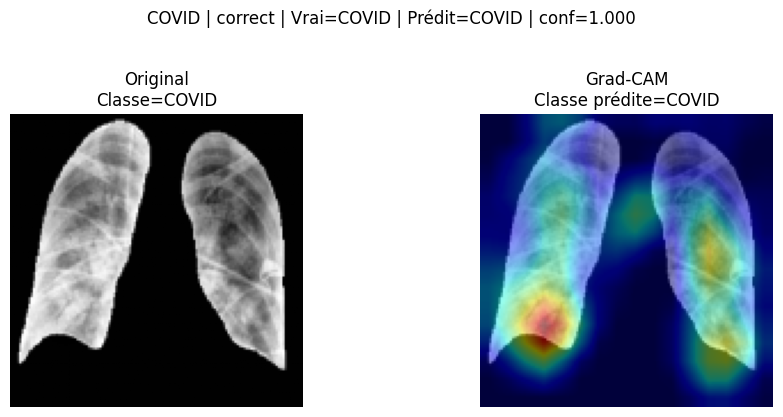

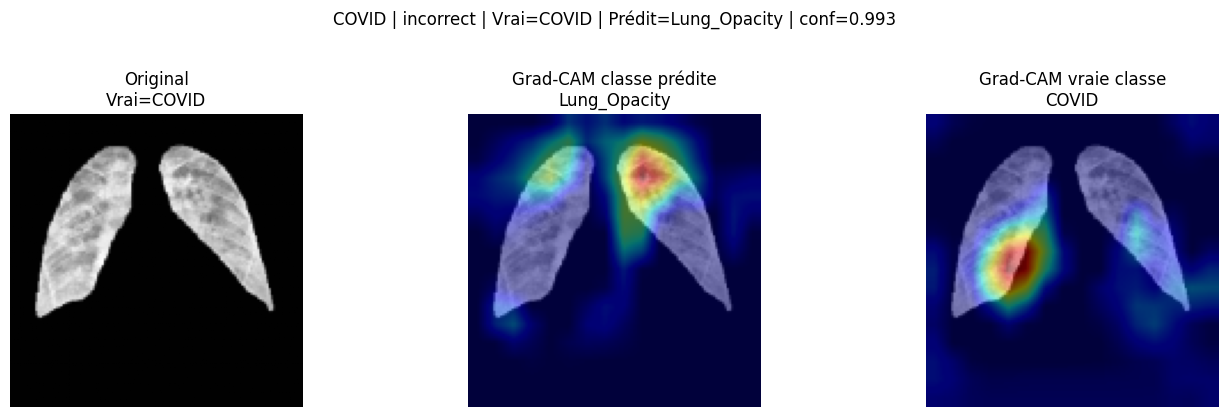

Grad-CAM — catégorie : Normal


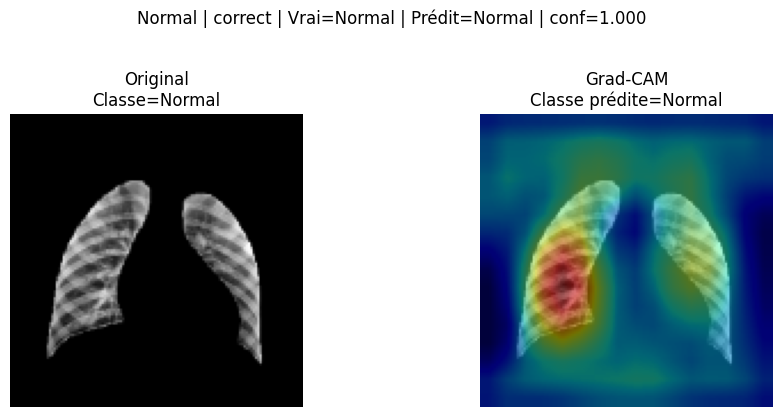

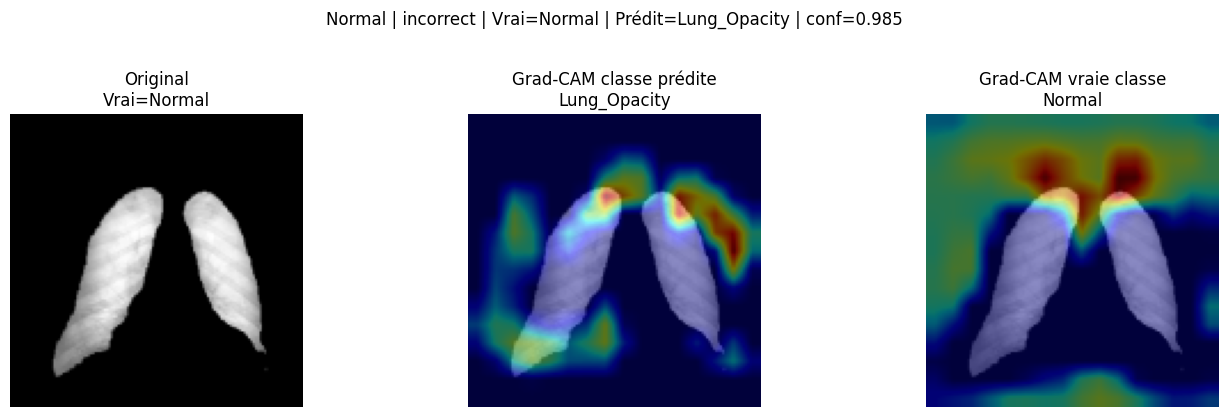

Grad-CAM — catégorie : Lung_Opacity


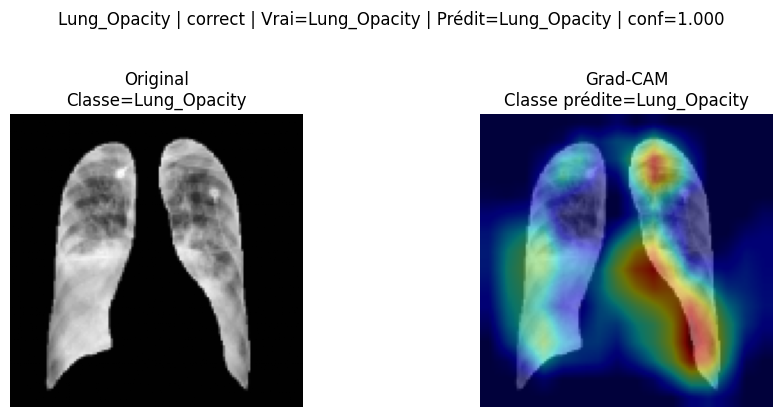

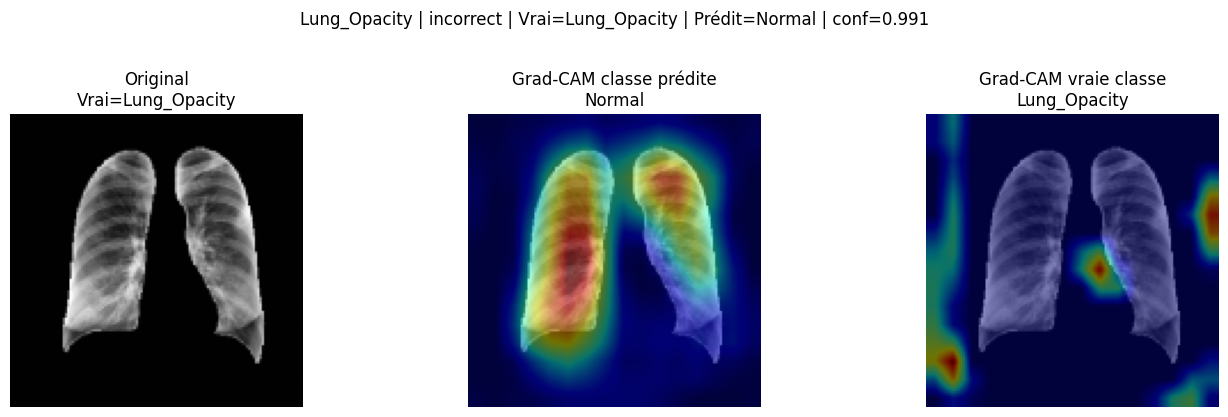

Grad-CAM — catégorie : Viral Pneumonia


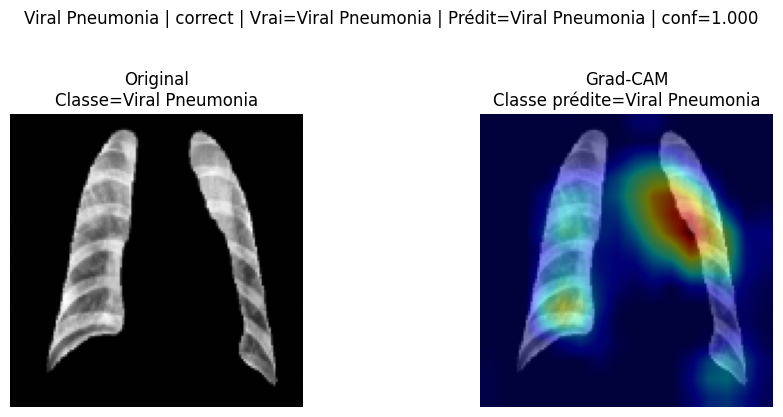

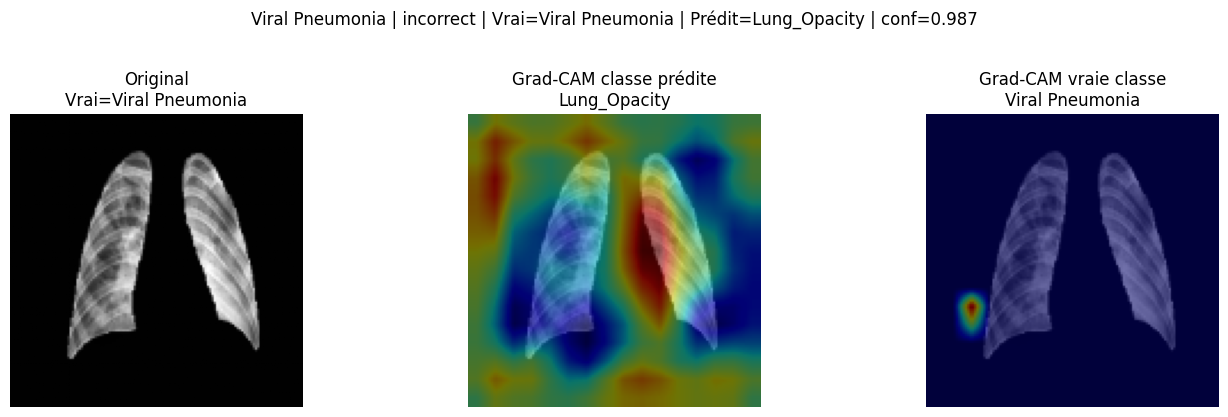

In [27]:
# =========================
# Affichage Grad-CAM pour les exemples sélectionnés
# =========================

def show_gradcam_for_row(row, model, last_conv_layer_name):
    image_np = load_preprocessed_image_from_row(row)
    batch = np.expand_dims(image_np, axis=0).astype(np.float32)

    true_id = int(row["y_true"])
    pred_id = int(row["y_pred"])

    pred_heatmap = make_gradcam_heatmap(batch, model, last_conv_layer_name, class_index=pred_id)
    pred_overlay = overlay_gradcam_on_image(image_np, pred_heatmap)

    if true_id != pred_id:
        true_heatmap = make_gradcam_heatmap(batch, model, last_conv_layer_name, class_index=true_id)
        true_overlay = overlay_gradcam_on_image(image_np, true_heatmap)

        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        axes[0].imshow(image_np.squeeze(), cmap="gray")
        axes[0].set_title(f"Original\nVrai={ID_TO_CLASS[true_id]}")
        axes[0].axis("off")

        axes[1].imshow(pred_overlay)
        axes[1].set_title(f"Grad-CAM classe prédite\n{ID_TO_CLASS[pred_id]}")
        axes[1].axis("off")

        axes[2].imshow(true_overlay)
        axes[2].set_title(f"Grad-CAM vraie classe\n{ID_TO_CLASS[true_id]}")
        axes[2].axis("off")
    else:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].imshow(image_np.squeeze(), cmap="gray")
        axes[0].set_title(f"Original\nClasse={ID_TO_CLASS[true_id]}")
        axes[0].axis("off")

        axes[1].imshow(pred_overlay)
        axes[1].set_title(f"Grad-CAM\nClasse prédite={ID_TO_CLASS[pred_id]}")
        axes[1].axis("off")

    plt.suptitle(
        f"{row['true_name']} | {row['example_type']} | "
        f"Vrai={row['true_name']} | Prédit={row['pred_name']} | conf={row['pred_confidence']:.3f}",
        y=1.03
    )
    plt.tight_layout()
    plt.show()

for category in CATEGORIES:
    cat_subset = examples_df[examples_df["true_name"] == category]
    if len(cat_subset) == 0:
        print(f"Aucun exemple sélectionné pour {category}.")
        continue

    print("=" * 90)
    print(f"Grad-CAM — catégorie : {category}")
    print("=" * 90)

    for _, row in cat_subset.iterrows():
        show_gradcam_for_row(row, model, gradcam_layer_name)

In [ ]:
# =========================
# Nettoyage mémoire (optionnel)
# =========================

gc.collect()